## 0. Data preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import math

In [2]:
pfas = pd.read_csv('PFAS_data_130.csv')
pfas.head()

,Log Files,Molecule,SMILES,a0,a1,a2,a3,a4,H_f_0K,S(300K),...,F-C-C-C Torsions,F-C-C-F Torsions,F-C-C-O Torsions,F-C-O-C Torsions,O-C-C-C Torsions,O-C-C-F Torsions,O-C-C-O Torsions,O-C-O-C Torsions,O-O-C-C Torsions,O-O-C-F Torsions
0,butene.log,1C4F8,C(=C(F)C(C(F)(F)F)(F)F)(F)F,8.2447,0.13653,-0.000133,6.050000e-08,-1.040000e-11,-371.81,104.398839,...,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,butene_OH.log,1C4F8_OH,FC(O)(F)[C](C(F)(F)C(F)(F)F)F,8.9590,0.16092,-0.000159,7.290000e-08,-1.260000e-11,-419.97,44.901000,...,3.0,10.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,pentene.log,1C5F10,C(=C(F)C(C(F)(F)C(F)(F)F)(F)F)(F)F,10.0620,0.17448,-0.000171,7.770000e-08,-1.330000e-11,-470.07,119.440000,...,3.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,hexene.log,1C6F12,C(F)(F)(C(=C(F)F)F)C(C(C(F)(F)F)(F)F)(F)F,11.8020,0.21282,-0.000209,9.510000e-08,-1.630000e-11,-567.50,134.200000,...,5.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,heptene.log,1C7F14,C(F)(F)(C(=C(F)F)F)C(C(C(C(F)(F)F)(F)F)(F)F)(F)F,13.3720,0.25169,-0.000248,1.130000e-07,-1.940000e-11,-665.26,147.340000,...,7.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
X = pfas[pfas.columns[10:]]
X

,sp2 Pair Count C-C,sp2 Pair Count C-O,sp2 Pair Count O-O,sp2 Total Count,sp3 Pair Count C-C,sp3 Pair Count C-F,sp3 Pair Count C-O,sp3 Pair Count O-O,sp3 Total Count,Num. Atoms C,...,F-C-C-C Torsions,F-C-C-F Torsions,F-C-C-O Torsions,F-C-O-C Torsions,O-C-C-C Torsions,O-C-C-F Torsions,O-C-C-O Torsions,O-C-O-C Torsions,O-O-C-C Torsions,O-O-C-F Torsions
0,1.0,0.0,0.0,1.0,2.0,8.0,0.0,0.0,10.0,4.0,...,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,3.0,8.0,1.0,0.0,12.0,4.0,...,3.0,10.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,1.0,3.0,10.0,0.0,0.0,13.0,5.0,...,3.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,1.0,4.0,12.0,0.0,0.0,16.0,6.0,...,5.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,5.0,14.0,0.0,0.0,19.0,7.0,...,7.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,0.0,0.0,0.0,0.0,3.0,9.0,0.0,0.0,12.0,4.0,...,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
126,0.0,0.0,0.0,0.0,4.0,11.0,0.0,0.0,15.0,5.0,...,3.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
127,0.0,0.0,0.0,0.0,5.0,13.0,0.0,0.0,18.0,6.0,...,5.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
128,0.0,0.0,0.0,0.0,6.0,15.0,0.0,0.0,21.0,7.0,...,7.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
Y = pfas[pfas.columns[4]]
Y

0      0.13653
1      0.16092
2      0.17448
3      0.21282
4      0.25169
        ...   
125    0.16006
126    0.19066
127    0.22917
128    0.26726
129    0.30607
Name: a1, Length: 130, dtype: float64

In [5]:
XY = pd.concat([X,Y], axis = 1)
XY

,sp2 Pair Count C-C,sp2 Pair Count C-O,sp2 Pair Count O-O,sp2 Total Count,sp3 Pair Count C-C,sp3 Pair Count C-F,sp3 Pair Count C-O,sp3 Pair Count O-O,sp3 Total Count,Num. Atoms C,...,F-C-C-F Torsions,F-C-C-O Torsions,F-C-O-C Torsions,O-C-C-C Torsions,O-C-C-F Torsions,O-C-C-O Torsions,O-C-O-C Torsions,O-O-C-C Torsions,O-O-C-F Torsions,a1
0,1.0,0.0,0.0,1.0,2.0,8.0,0.0,0.0,10.0,4.0,...,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.13653
1,0.0,0.0,0.0,0.0,3.0,8.0,1.0,0.0,12.0,4.0,...,10.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.16092
2,1.0,0.0,0.0,1.0,3.0,10.0,0.0,0.0,13.0,5.0,...,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.17448
3,1.0,0.0,0.0,1.0,4.0,12.0,0.0,0.0,16.0,6.0,...,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.21282
4,1.0,0.0,0.0,1.0,5.0,14.0,0.0,0.0,19.0,7.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,0.0,0.0,0.0,0.0,3.0,9.0,0.0,0.0,12.0,4.0,...,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.16006
126,0.0,0.0,0.0,0.0,4.0,11.0,0.0,0.0,15.0,5.0,...,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.19066
127,0.0,0.0,0.0,0.0,5.0,13.0,0.0,0.0,18.0,6.0,...,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.22917
128,0.0,0.0,0.0,0.0,6.0,15.0,0.0,0.0,21.0,7.0,...,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.26726


## 1. Feature selection with correlation matrix

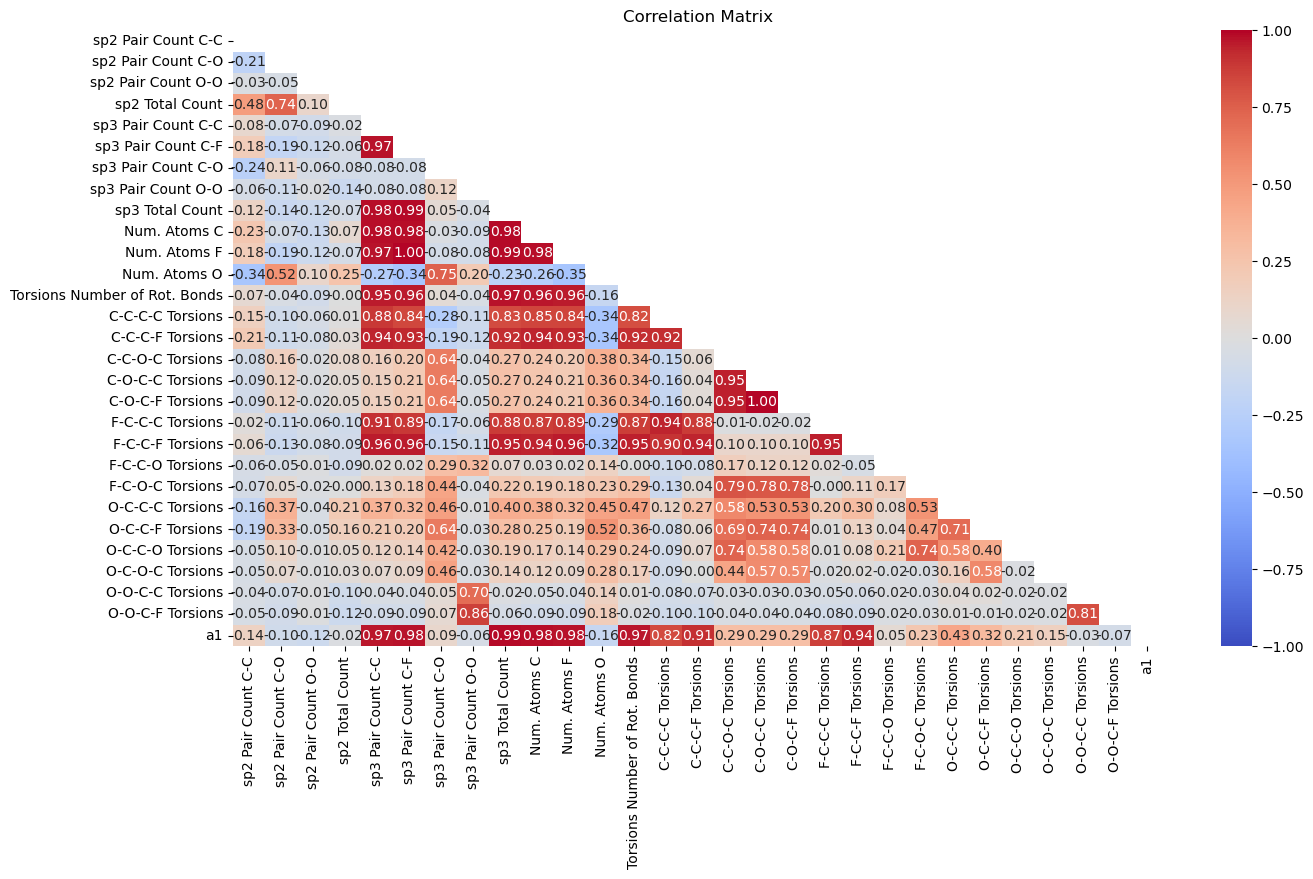

In [6]:
XY_corr = XY.corr(method='pearson')
plt.figure(figsize=(15,8))
mask = np.triu(np.ones_like(XY_corr, dtype=bool))
sns.heatmap(XY_corr, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [7]:
n_descps = len(X.columns) - 1
high_threshold = 0.9
low_threshold = 0.01

# excluding low correlation with a0
for descr in X.columns:
    res_y = stats.linregress(Y, X[descr])
    rsquared_y = res_y.rvalue**2
    if rsquared_y < low_threshold:
        print(f"{descr} has low correlation with a0, removing it")
        X.drop(columns=[descr], inplace = True)
        n_descps -= 1

# detecting descriptors that are strongly correlated with each other
descp_drop = set()
cols = list(X.columns)

for i, col1 in enumerate(cols):
    if col1 in descp_drop:
        continue  # skip if already removed

    for j in range(i + 1, len(cols)):
        col2 = cols[j]
        if col2 in descp_drop:
            continue  # skip if already removed

        res_x = stats.linregress(X[col2], X[col1])
        rsquared = res_x.rvalue**2

        if rsquared > high_threshold:
            print(f"{col1} has high correlation with {col2}")
            
            # Check which one is more strongly correlated with the target
            res_iy = stats.linregress(Y, X[col2])
            rsquared_iy = res_iy.rvalue**2
            res_jy = stats.linregress(Y, X[col1])
            rsquared_jy = res_jy.rvalue**2

            if rsquared_iy > rsquared_jy:
                print(f"--> Removing {col2}")
                descp_drop.add(col2)
            else:
                print(f"--> Removing {col1}")
                descp_drop.add(col1)
                break  # Stop checking col1 if it's removed

# drop descriptors
print("Dropping descriptors:", descp_drop)
X.drop(columns=descp_drop, inplace=True)
n_descps = len(X.columns) - 1
print(f"Number of descriptors after filtering: {n_descps}")
X.head()

sp2 Pair Count C-O has low correlation with a0, removing it
sp2 Total Count has low correlation with a0, removing it
sp3 Pair Count C-O has low correlation with a0, removing it
sp3 Pair Count O-O has low correlation with a0, removing it
F-C-C-O Torsions has low correlation with a0, removing it
O-O-C-C Torsions has low correlation with a0, removing it
O-O-C-F Torsions has low correlation with a0, removing it
sp3 Pair Count C-C has high correlation with sp3 Pair Count C-F
--> Removing sp3 Pair Count C-F
sp3 Pair Count C-C has high correlation with sp3 Total Count
--> Removing sp3 Total Count
sp3 Pair Count C-C has high correlation with Num. Atoms C
--> Removing Num. Atoms C
sp3 Pair Count C-C has high correlation with Num. Atoms F
--> Removing Num. Atoms F
sp3 Pair Count C-C has high correlation with Torsions Number of Rot. Bonds
--> Removing Torsions Number of Rot. Bonds
sp3 Pair Count C-C has high correlation with F-C-C-F Torsions
--> Removing sp3 Pair Count C-C
C-O-C-C Torsions has hi

/tmp/ipykernel_1170498/1005772786.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(columns=[descr], inplace = True)
/tmp/ipykernel_1170498/1005772786.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(columns=[descr], inplace = True)
/tmp/ipykernel_1170498/1005772786.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(columns=[descr], inplace = True)
/tmp/ipykernel_1170498/1005772786.py:11: SettingWithCopyWa

,sp2 Pair Count C-C,sp2 Pair Count O-O,Num. Atoms O,C-C-C-C Torsions,C-C-C-F Torsions,C-C-O-C Torsions,C-O-C-F Torsions,F-C-C-C Torsions,F-C-O-C Torsions,O-C-C-C Torsions,O-C-C-F Torsions,O-C-C-O Torsions,O-C-O-C Torsions
0,1.0,0.0,0.0,1.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,5.0,0.0,0.0,3.0,0.0,1.0,1.0,0.0,0.0
2,1.0,0.0,0.0,2.0,7.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,3.0,9.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,4.0,11.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0


## 2. A glimpse of chemical space with UMAP and 4 different ways of scaling

In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler
import umap

/home/ngohviet/.conda/envs/chem480a5/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# try 3 different ways of scaling data
X_SS = StandardScaler(with_mean=False).fit_transform(X)
X_MMS = MinMaxScaler().fit_transform(X)
X_MAS = MaxAbsScaler().fit_transform(X)

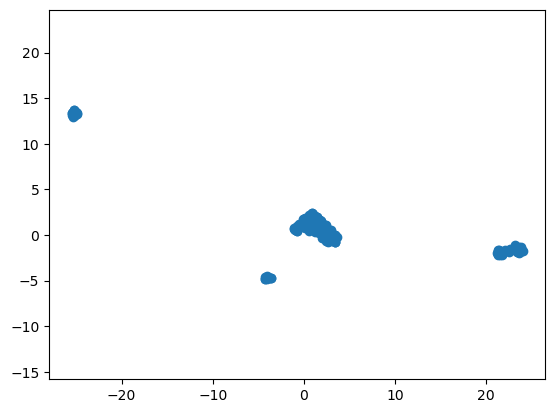

In [10]:
# UMAP for no scaling data
reducer = umap.UMAP(n_components = 2)
embedding = reducer.fit_transform(X)

plt.scatter(
    embedding[:, 0],
    embedding[:, 1])
plt.gca().set_aspect('equal', 'datalim')

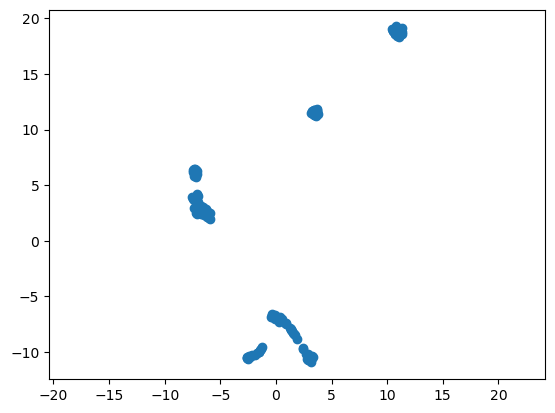

In [11]:
# UMAP for standard scaling data
reducer1 = umap.UMAP(n_components = 2)
embedding_SS = reducer1.fit_transform(X_SS)

plt.scatter(
    embedding_SS[:, 0],
    embedding_SS[:, 1])
plt.gca().set_aspect('equal', 'datalim')

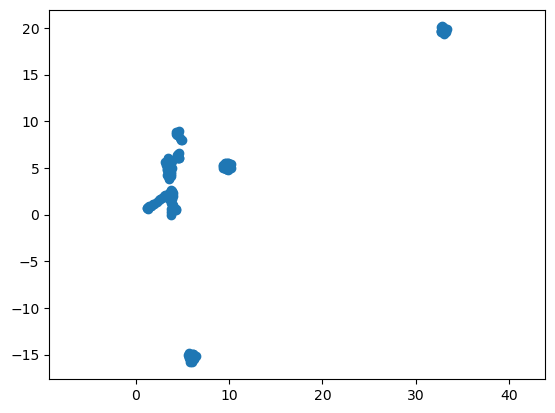

In [12]:
# UMAP for min max scaling data
reducer2 = umap.UMAP(n_components = 2)
embedding_MMS = reducer2.fit_transform(X_MMS)

plt.scatter(
    embedding_MMS[:, 0],
    embedding_MMS[:, 1])
plt.gca().set_aspect('equal', 'datalim')

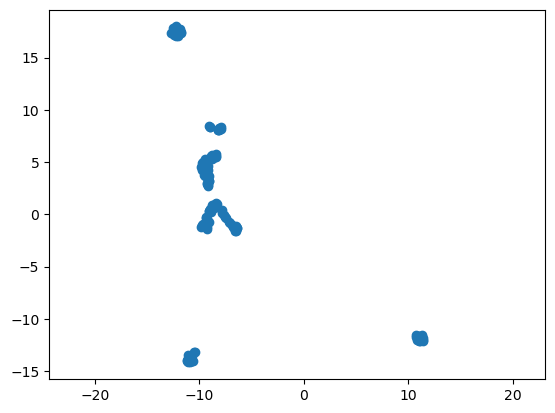

In [13]:
# UMAP for max abs scaling data
reducer3 = umap.UMAP(n_components = 2)
embedding_MAS = reducer3.fit_transform(X_MAS)

plt.scatter(
    embedding_MAS[:, 0],
    embedding_MAS[:, 1])
plt.gca().set_aspect('equal', 'datalim')

**We can see that data forms different clusters, so random split might not be a good idea, but I haven't figured out how to access to each cluster to split them yet.**

## 3. Predicting a1 with Standard Scaling data, random split and some simple models

In [14]:
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.neural_network import MLPRegressor
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn_evaluation import plot
from sklearn.inspection import permutation_importance

In [15]:
# Fit model and compute regression scores (R2), including CV:
def report_regression_scores(model, X_train, y_train, X_test, y_test, X, y, cv):
    # fit & predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    # --- holdout (train/test split) metrics ---
    train_r2   = metrics.r2_score(y_train, y_train_pred)
    test_r2    = metrics.r2_score(y_test, y_pred)

    # --- cross-validation metrics ---
    scores = cross_validate(
        model, X, y,
        cv=cv,                    
        return_train_score=True,
        scoring='r2',
    )
    scores_table = pd.DataFrame(scores)

    train_cv_scores = np.round(scores_table["train_score"].values, 3)
    test_cv_scores  = np.round(scores_table["test_score"].values, 3)

    # Build & return a summary table
    summary_df = pd.DataFrame({
        "Train R2":   [round(train_r2,3)],
        "Test R2":    [round(test_r2,3)],
        "Train CV Scores": [train_cv_scores],
        "Test CV Scores": [test_cv_scores],
    }, index=[model.__class__.__name__])

    return summary_df

In [16]:
# Print permutation feature importance
def print_permutation_importance(model, X_train, y_train, X_test, y_test, feature_names, n_repeats=30, random_state=15):
    
    model.fit(X_train, y_train)
    r = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=random_state)

    print(f"\nPermutation importances for {model.__class__.__name__}:")
    print(f"{'Feature':<20} Mean ± Std")
    for idx in r.importances_mean.argsort()[::-1]:
        mean, std = r.importances_mean[idx], r.importances_std[idx]
        if mean - 2*std > 0:
            print(f"{feature_names[idx]:<20} {mean:.3f} ± {std:.3f}")
    return r

In [17]:
# Plot permutation feature importance
def plot_permutation_importance(models, X_train, y_train, X_test, y_test, feature_names, cols, n_features, n_repeats=30, random_state=15):
    # create subplots
    n = len(models)
    rows = math.ceil(n/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
    if n == 1:
        axes = [axes]    
    axes = axes.flatten()

    # fit model and plot permutation feature importance 
    for ax, model in zip(axes, models):
        model.fit(X_train, y_train)
        r = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=random_state)
        idxs = r.importances_mean.argsort()[::-1]

        ax.barh(range(len(idxs)), r.importances_mean[idxs], xerr=r.importances_std[idxs], align='center')
        ax.set_yticks(range(len(idxs)))
        ax.set_yticklabels([feature_names[i] for i in idxs])
        ax.invert_yaxis()
        ax.set_title(f"{model.__class__.__name__}")
        ax.set_xlabel("Permutation Importance")

    for empty_ax in axes[len(models):]:
        empty_ax.set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f"PFI_{n_features}features.png",        
            dpi=300,
            bbox_inches='tight')
    plt.show()

In [19]:
# list out all the models I wanna try
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))

models = [Ridge(alpha=0.5, random_state=42), 
          Lasso(alpha=0.01, random_state=42),
          ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
          SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
          KNeighborsRegressor(n_neighbors=11, weights="distance", metric="minkowski",p=1),
          GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42),
          RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=2, random_state=42),
          DecisionTreeRegressor(random_state=42),
          GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, alpha=1e-8, random_state=42),
          MLPRegressor(
              hidden_layer_sizes=(32,16),
              activation="relu",
              solver="adam",
              alpha=1e-3,
              learning_rate_init=1e-3,
              max_iter=5000,
              early_stopping=True,
              validation_fraction=0.2,
              n_iter_no_change=30,
              random_state=1)]

### Try different train/test split ratio

**Train/Test = 90:10**

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.1, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=10)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.952,0.812,"[0.94, 0.955, 0.952, 0.927, 0.944, 0.943, 0.94...","[0.953, -3.482, 0.439, 0.967, -0.029, 0.289, 0..."
Lasso,0.918,0.762,"[0.908, 0.919, 0.922, 0.875, 0.91, 0.908, 0.91...","[0.847, -0.645, 0.359, -0.393, -0.525, -0.718,..."
ElasticNet,0.937,0.791,"[0.926, 0.937, 0.939, 0.905, 0.929, 0.927, 0.9...","[0.861, -1.333, 0.349, 0.653, -0.196, -0.196, ..."
SVR,0.612,0.467,"[0.598, 0.614, 0.611, 0.535, 0.614, 0.61, 0.62...","[0.138, -4.366, 0.384, -3.425, -7.026, -7.467,..."
KNeighborsRegressor,0.961,0.669,"[0.955, 0.969, 0.959, 0.946, 0.962, 0.962, 0.9...","[0.711, -3.585, -0.738, -0.106, 0.162, 0.059, ..."
GradientBoostingRegressor,0.960,0.830,"[0.957, 0.966, 0.961, 0.947, 0.96, 0.959, 0.96...","[0.909, -3.469, 0.421, 0.706, -0.162, 0.185, 0..."
RandomForestRegressor,0.952,0.838,"[0.948, 0.957, 0.952, 0.935, 0.951, 0.949, 0.9...","[0.914, -3.272, 0.282, 0.772, -0.424, 0.103, 0..."
DecisionTreeRegressor,0.962,0.846,"[0.958, 0.969, 0.961, 0.949, 0.963, 0.962, 0.9...","[0.848, -5.481, 0.521, 0.735, -0.108, 0.088, 0..."
GaussianProcessRegressor,0.952,0.813,"[0.939, 0.956, 0.952, 0.927, 0.944, 0.942, 0.9...","[0.937, -3.367, 0.347, 0.951, -0.053, 0.264, 0..."
MLPRegressor,0.229,-4.167,"[0.917, 0.952, 0.948, 0.929, 0.937, 0.937, 0.9...","[0.197, -3.951, -2.905, 0.829, -0.114, 0.007, ..."


Clearly overfit: Test R2 < Train R2, and cross-validation (CV) R2 values vary by a lot.

**Train/Test = 83.3:16.7**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.167, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=6)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.950,0.892,"[0.95, 0.95, 0.931, 0.943, 0.944, 0.953]","[0.878, 0.816, 0.978, -0.351, 0.856, 0.827]"
Lasso,0.912,0.833,"[0.918, 0.923, 0.886, 0.908, 0.914, 0.915]","[0.894, 0.766, 0.945, -2.074, 0.535, 0.902]"
ElasticNet,0.935,0.883,"[0.934, 0.939, 0.912, 0.929, 0.929, 0.934]","[0.882, 0.783, 0.972, -1.271, 0.62, 0.895]"
SVR,0.617,0.501,"[0.599, 0.611, 0.564, 0.61, 0.597, 0.57]","[0.561, 0.501, 0.624, -8.386, 0.449, 0.389]"
KNeighborsRegressor,0.959,0.785,"[0.965, 0.957, 0.953, 0.963, 0.962, 0.967]","[0.795, 0.4, 0.917, -0.077, 0.577, 0.762]"
GradientBoostingRegressor,0.958,0.916,"[0.964, 0.959, 0.952, 0.959, 0.962, 0.967]","[0.877, 0.668, 0.962, -0.01, 0.711, 0.807]"
RandomForestRegressor,0.950,0.899,"[0.955, 0.952, 0.94, 0.947, 0.95, 0.958]","[0.882, 0.665, 0.961, -0.029, 0.607, 0.82]"
DecisionTreeRegressor,0.959,0.907,"[0.966, 0.96, 0.955, 0.963, 0.964, 0.97]","[0.847, -0.248, 0.969, -0.077, 0.356, 0.764]"
GaussianProcessRegressor,0.950,0.898,"[0.95, 0.951, 0.931, 0.943, 0.945, 0.955]","[0.882, 0.769, 0.977, -0.503, 0.776, 0.831]"
MLPRegressor,0.885,-0.242,"[0.829, 0.855, 0.821, 0.84, 0.936, 0.943]","[-0.049, -0.247, 0.937, -0.409, -2.006, -0.695]"


* Clearly overfit except GBR, RFR, DTR (these were overfitting when predicting a0), GPR, Ridge, and ElasticNet (works well for both).
* CV scores are still a problem.

**Train/Test = 80/20**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.2, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=5)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.952,0.898,"[0.951, 0.935, 0.94, 0.948, 0.953]","[0.887, 0.872, 0.073, 0.793, 0.849]"
Lasso,0.913,0.864,"[0.92, 0.895, 0.904, 0.921, 0.914]","[0.898, 0.543, -0.897, 0.494, 0.904]"
ElasticNet,0.935,0.899,"[0.936, 0.919, 0.925, 0.934, 0.934]","[0.883, 0.738, -0.333, 0.553, 0.905]"
SVR,0.601,0.517,"[0.607, 0.536, 0.607, 0.624, 0.568]","[0.532, 0.295, -7.072, 0.267, 0.434]"
KNeighborsRegressor,0.960,0.802,"[0.965, 0.944, 0.963, 0.969, 0.967]","[0.824, 0.637, -0.377, 0.585, 0.814]"
GradientBoostingRegressor,0.960,0.902,"[0.965, 0.947, 0.96, 0.967, 0.967]","[0.874, 0.904, -0.341, 0.714, 0.837]"
RandomForestRegressor,0.952,0.898,"[0.955, 0.937, 0.95, 0.955, 0.957]","[0.882, 0.9, -0.615, 0.585, 0.86]"
DecisionTreeRegressor,0.961,0.906,"[0.966, 0.948, 0.963, 0.969, 0.969]","[0.837, 0.859, -0.469, 0.677, 0.78]"
GaussianProcessRegressor,0.952,0.904,"[0.951, 0.935, 0.939, 0.949, 0.954]","[0.896, 0.844, 0.003, 0.743, 0.855]"
MLPRegressor,0.895,0.060,"[0.936, 0.931, 0.878, 0.902, 0.893]","[-0.017, 0.529, -0.406, -1.971, -0.556]"


* Same as above.

**Train/Test = 75:25**

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.947,0.926,"[0.959, 0.925, 0.947, 0.952]","[0.839, 0.979, 0.789, 0.879]"
Lasso,0.906,0.896,"[0.932, 0.879, 0.909, 0.911]","[0.846, 0.894, 0.485, 0.744]"
ElasticNet,0.929,0.923,"[0.947, 0.908, 0.935, 0.933]","[0.828, 0.956, 0.599, 0.838]"
SVR,0.573,0.555,"[0.611, 0.553, 0.64, 0.568]","[0.528, 0.609, 0.057, 0.424]"
KNeighborsRegressor,0.957,0.846,"[0.965, 0.95, 0.972, 0.967]","[0.627, 0.917, 0.65, 0.774]"
GradientBoostingRegressor,0.956,0.925,"[0.965, 0.95, 0.968, 0.967]","[0.771, 0.96, 0.783, 0.872]"
RandomForestRegressor,0.947,0.925,"[0.958, 0.937, 0.95, 0.957]","[0.76, 0.96, 0.758, 0.872]"
DecisionTreeRegressor,0.957,0.923,"[0.966, 0.951, 0.972, 0.968]","[0.385, 0.961, 0.809, 0.834]"
GaussianProcessRegressor,0.946,0.930,"[0.959, 0.925, 0.947, 0.953]","[0.827, 0.976, 0.749, 0.862]"
MLPRegressor,0.905,0.458,"[0.918, 0.889, 0.303, 0.881]","[-0.573, 0.962, -11.367, -1.489]"


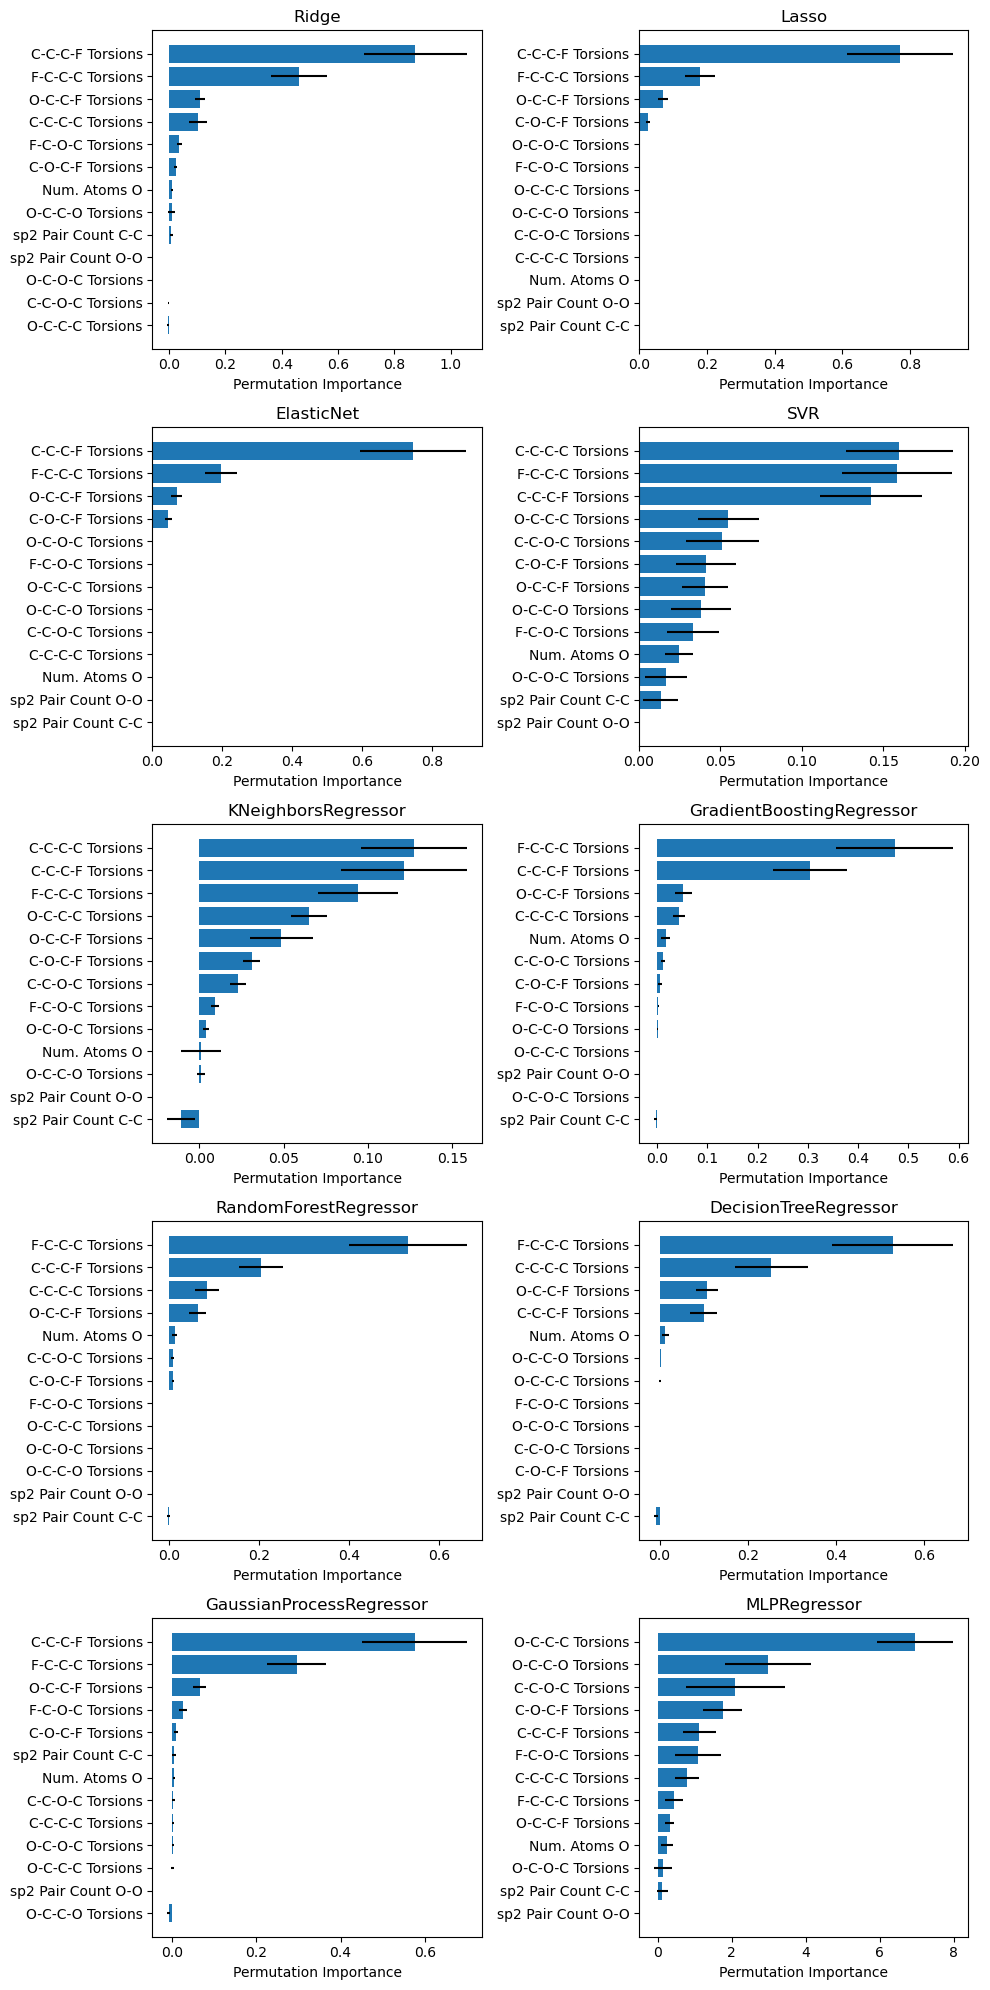

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.25, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=4)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

# big subplot of permutation feature importance
plot_permutation_importance(models, X_train, y_train, X_test, y_test, list(X.columns), cols=2, n_features=11)

* Comparing train and test scores, all of them except MLP and kNN are not overfitting.
* All of them except SVR and MLP have high performance.
* Look at the CV scores, we can pick out the best model: Ridge (this one also works well in predicting a0).
* However, the others' variety in CV scores can be fixed by not random splitting.
* Permutation feature importance: only 4 descriptors needed.

**Train/Test = 66.7:33.3**

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.945,0.938,"[0.956, 0.924, 0.952]","[0.858, 0.943, 0.892]"
Lasso,0.904,0.896,"[0.933, 0.876, 0.922]","[0.845, 0.861, 0.668]"
ElasticNet,0.929,0.927,"[0.946, 0.907, 0.931]","[0.839, 0.908, 0.679]"
SVR,0.584,0.540,"[0.599, 0.55, 0.569]","[0.55, 0.495, 0.434]"
KNeighborsRegressor,0.955,0.839,"[0.962, 0.956, 0.971]","[0.626, 0.887, 0.638]"
GradientBoostingRegressor,0.955,0.915,"[0.963, 0.953, 0.97]","[0.783, 0.925, 0.721]"
RandomForestRegressor,0.944,0.923,"[0.956, 0.937, 0.959]","[0.753, 0.916, 0.712]"
DecisionTreeRegressor,0.955,0.906,"[0.963, 0.956, 0.972]","[0.491, 0.928, 0.703]"
GaussianProcessRegressor,0.944,0.936,"[0.956, 0.923, 0.954]","[0.835, 0.934, 0.833]"
MLPRegressor,0.770,-0.308,"[0.937, -0.319, 0.958]","[0.082, 0.677, 0.52]"


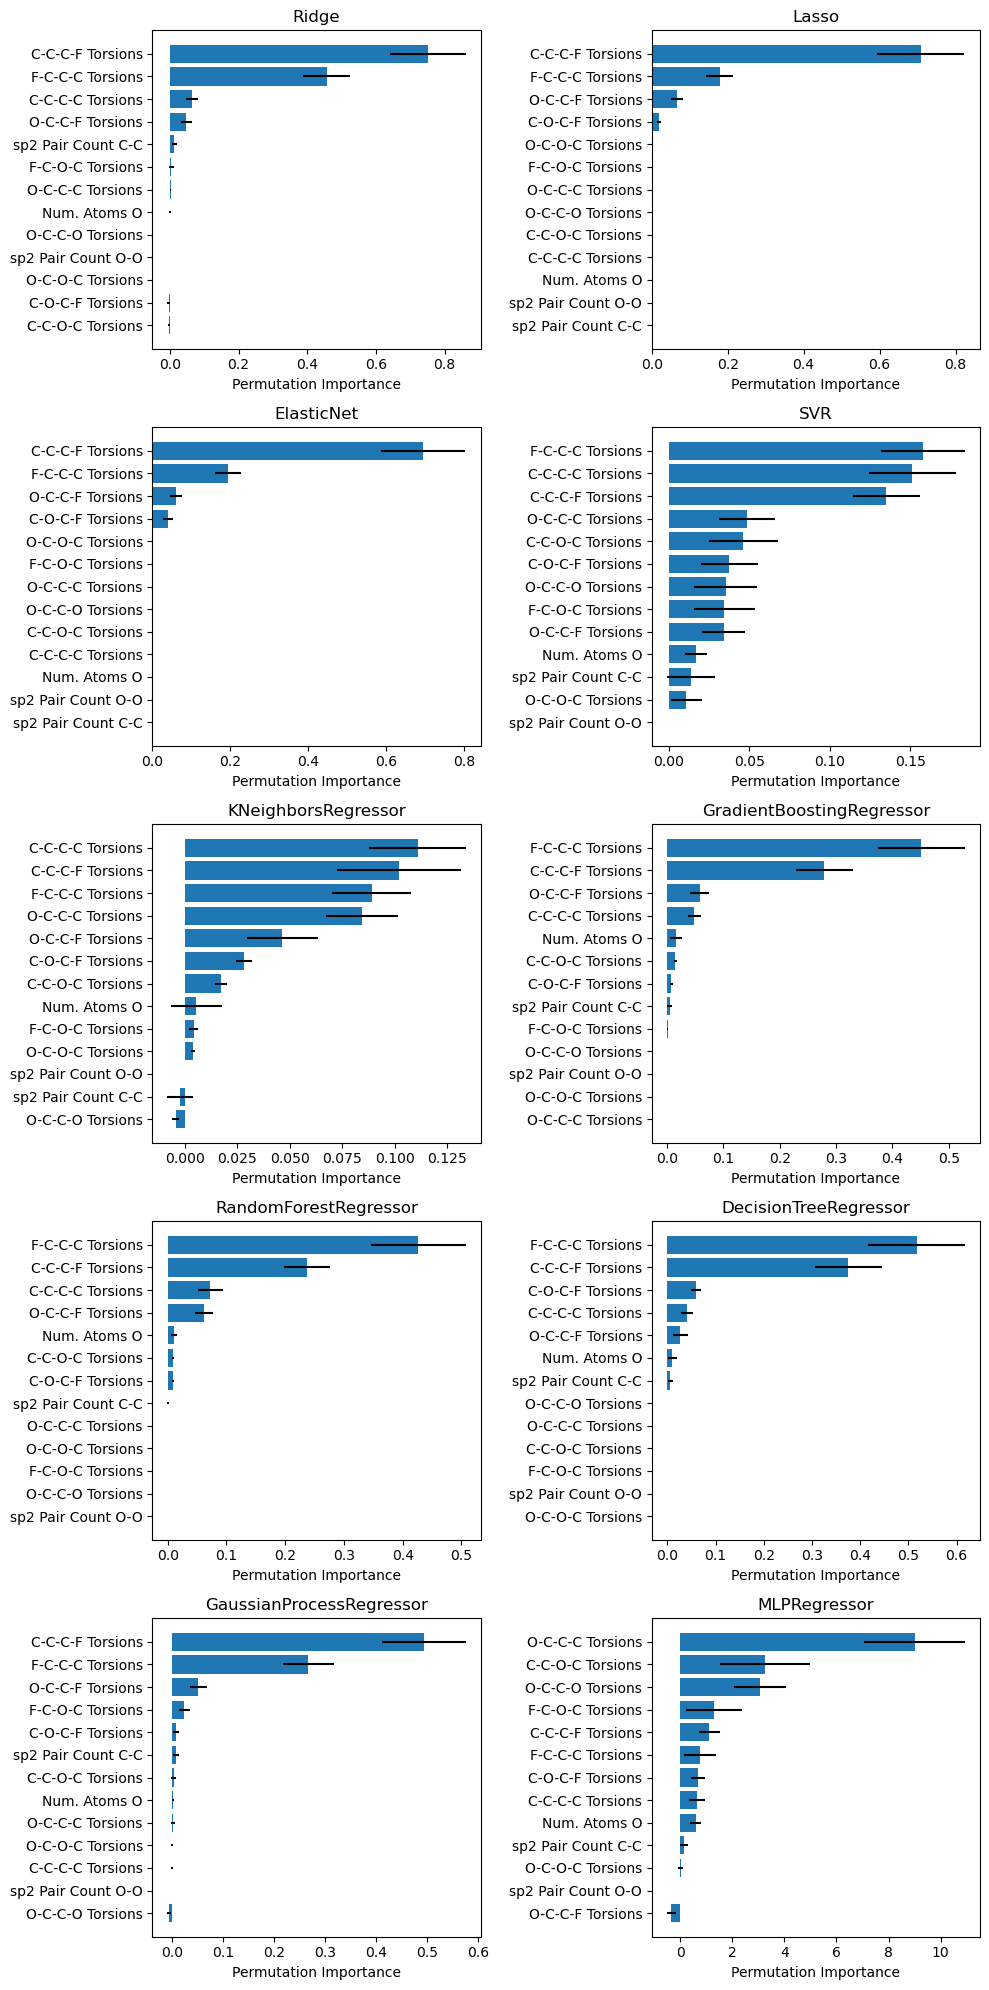

In [27]:
# Try 66.7/33.3 train/test split 
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.333, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=3)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

# big subplot of permutation feature importance
plot_permutation_importance(models, X_train, y_train, X_test, y_test, list(X.columns), cols=2, n_features=11)

* Same as above except that the CV score problem is even solved better.

**Train/Test = 50:50**

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.935,0.948,"[0.941, 0.957]","[0.906, 0.871]"
Lasso,0.894,0.911,"[0.913, 0.934]","[0.77, 0.717]"
ElasticNet,0.920,0.938,"[0.932, 0.944]","[0.846, 0.736]"
GaussianProcessRegressor,0.934,0.929,"[0.941, 0.958]","[0.903, 0.845]"
GradientBoostingRegressor,0.951,0.926,"[0.951, 0.979]","[0.895, 0.778]"
RandomForestRegressor,0.939,0.917,"[0.94, 0.962]","[0.897, 0.777]"
DecisionTreeRegressor,0.952,0.909,"[0.951, 0.98]","[0.809, 0.756]"


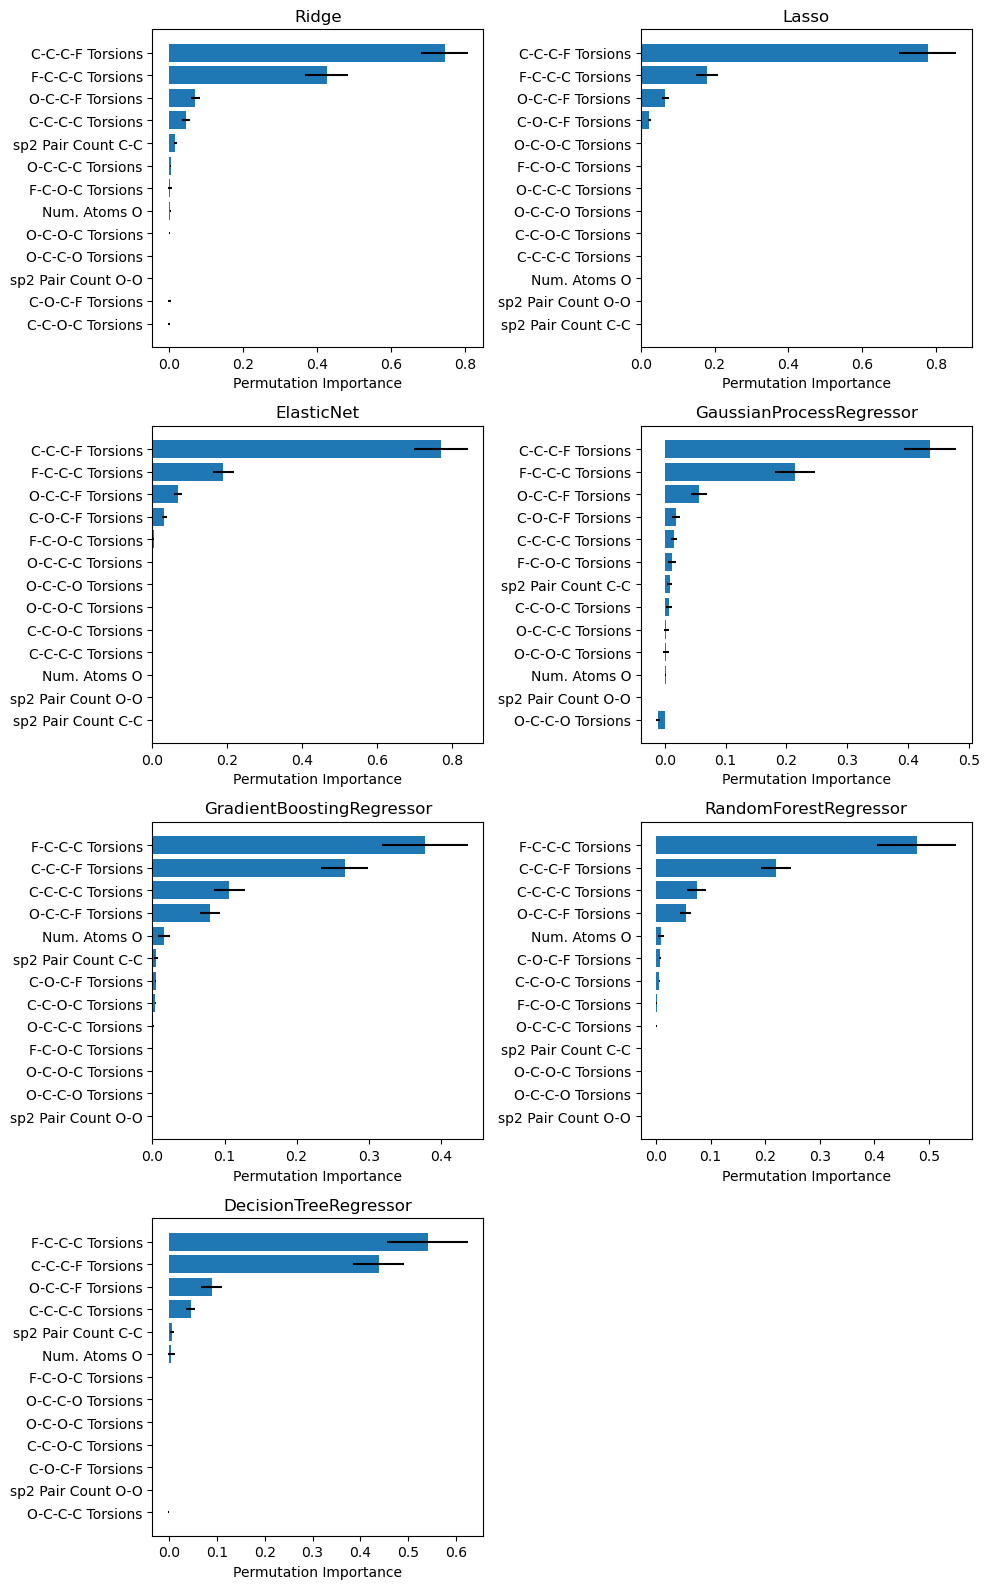

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.5, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=2)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

# big subplot of permutation feature importance
plot_permutation_importance(models, X_train, y_train, X_test, y_test, list(X.columns), cols=2, n_features=11)

* Same as above.

### Overall conclusion:
- At higher lower train/test splitting ratios than 75:25, the performance across models is quite good in both the high R2 and with less overfitting. This is much better than predicting a0. This is just screening, so there's still optimization to do to get a higher R2.
- Cross-validation scores could be fixed by splitting better (not by random split, but by addressing clusters).
- Permutation feature importance shows that there are only 4 descriptors that matter. We might need more descriptors. I wonder if descriptors involving S atoms are missing here.

## 4. Try fitting data with Max Abs Scaling

In [29]:
# list out all the models I wanna try
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))

models = [Ridge(alpha=0.5, random_state=42), 
          Lasso(alpha=0.01, random_state=42),
          ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
          GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, alpha=1e-8, random_state=42),
          GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42),
          RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=2, random_state=42),
          DecisionTreeRegressor(random_state=42)]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_MAS, Y, test_size=0.25, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MAS, Y, cv=4)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.935,0.936,"[0.949, 0.916, 0.942, 0.941]","[0.811, 0.967, 0.745, 0.881]"
Lasso,0.671,0.649,"[0.714, 0.585, 0.701, 0.698]","[0.848, 0.621, -0.229, 0.636]"
ElasticNet,0.797,0.766,"[0.858, 0.773, 0.828, 0.819]","[0.872, 0.781, 0.152, 0.733]"
GaussianProcessRegressor,0.947,0.935,"[0.96, 0.926, 0.947, 0.953]","[0.824, 0.978, 0.783, 0.886]"
GradientBoostingRegressor,0.956,0.925,"[0.965, 0.95, 0.968, 0.967]","[0.771, 0.96, 0.776, 0.861]"
RandomForestRegressor,0.947,0.925,"[0.957, 0.936, 0.95, 0.957]","[0.759, 0.96, 0.754, 0.875]"
DecisionTreeRegressor,0.957,0.923,"[0.966, 0.951, 0.972, 0.968]","[0.385, 0.961, 0.809, 0.804]"


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_MAS, Y, test_size=0.333, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MAS, Y, cv=3)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.934,0.937,"[0.949, 0.916, 0.942]","[0.8, 0.918, 0.818]"
Lasso,0.683,0.637,"[0.716, 0.53, 0.75]","[0.792, 0.379, 0.428]"
ElasticNet,0.799,0.753,"[0.866, 0.756, 0.875]","[0.849, 0.685, 0.564]"
GaussianProcessRegressor,0.945,0.944,"[0.958, 0.923, 0.954]","[0.83, 0.936, 0.872]"
GradientBoostingRegressor,0.955,0.915,"[0.963, 0.953, 0.97]","[0.783, 0.925, 0.719]"
RandomForestRegressor,0.944,0.923,"[0.955, 0.937, 0.959]","[0.752, 0.916, 0.706]"
DecisionTreeRegressor,0.955,0.906,"[0.963, 0.956, 0.972]","[0.491, 0.928, 0.703]"


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_MAS, Y, test_size=0.5, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MAS, Y, cv=2)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.923,0.941,"[0.933, 0.949]","[0.883, 0.793]"
Lasso,0.683,0.661,"[0.66, 0.759]","[0.654, 0.387]"
ElasticNet,0.796,0.773,"[0.84, 0.89]","[0.727, 0.595]"
GaussianProcessRegressor,0.935,0.948,"[0.943, 0.957]","[0.903, 0.853]"
GradientBoostingRegressor,0.951,0.924,"[0.951, 0.979]","[0.895, 0.776]"
RandomForestRegressor,0.939,0.917,"[0.939, 0.961]","[0.897, 0.77]"
DecisionTreeRegressor,0.952,0.908,"[0.951, 0.98]","[0.809, 0.756]"


### Conclusion: 
- Doesn't change much of the result
- Lasso and ElasticNet perform a little bit worse in this scaling.

### What can we improve?
- The way we split data:
    * Random split might not be ideal. --> Need help for UMAP visualization, then access each cluster to split.
- The models we use:
    * Fine-tuning the parameters of models. --> Need to learn.
    * Use more models --> EasyML: need to learn.
    * Neural network!!! --> need to learn.
- We need to generate more descriptors.
- We can update 200 more molecules (hopefully help with less overfitting).
### Fact check: Is it true that only neural networks can predict multiple Y values?